In [11]:
# FRA OPPGAVEN FØR, TRENGER IKKE Å KOPIERES OVER!
%matplotlib inline
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq, fftshift

def IMEX_solver(*, 
                                kappa, 
                                X, Y, U0, 
                                t0, T, Nt,
                                g, coeff,
                                alpha=1.5):
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method 
    with a convex-concave splitting approach.

    Parameters:
    -----------
    kappa : float
        Diffusion coefficient for the biharmonic operator.
    X : ndarray
        2D array representing the x-coordinates of the grid.
    Y : ndarray
        2D array representing the y-coordinates of the grid.
    U0 : ndarray
        Initial condition for the solution.
    t0 : float
        Initial time.
    T : float
        Final time.
    Nt : int
        Number of time steps.
    g : callable or None
        Source term as a function of (X, Y, t). If None, no source term is applied.
    alpha : float, optional
        Convex-concave splitting parameter. Default is 1.5.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.

    """

    # Prepare relevant data for Fourier transform
    N, M = U0.shape
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))
    alpha_10, alpha_11, alpha_20, alpha_21, alpha_22, beta_1, beta_2 = coeff

    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")
    K2 = -(KX**2 + KY**2)
    K4 = K2**2

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Add your time-stepping loop here
    # Time stepping 
    t = t0 
    dt = (T-t0)/Nt

    # For convenience when plotting, computing errors, etc., 
    # return the initial solution and initial time.
    yield U_hat, t  

    
    while t < T-dt/2:
        # Compute source term in Fourier space if provided
        if g is not None:
            g_hat = fft2(g(X, Y, t + dt/2, kappa))
        else:
            g_hat = 0
        
        def NonLinear(U_hat):
            U = ifft2(U_hat).real
            NonLin = U**3 - (1 + alpha) * U
            return K2*fft2(NonLin)

        # Bruker Song metoden for å finne neste steglengde
        # U_hat er U^n
        U_hat_1 = (U_hat + dt * (NonLinear(U_hat) + g_hat)) / (1 + dt * (kappa * K4 - alpha * K2))
        U_hat_2 = (alpha_10 * U_hat + alpha_11 * U_hat_1 + beta_1 * dt * (NonLinear(U_hat_1) + g_hat)) / (1 + beta_1 * dt * (kappa * K4 - alpha * K2))
        U_hat = (alpha_20 * U_hat + alpha_21 * U_hat_1 + alpha_22 * U_hat_2 + beta_2 * dt * (NonLinear(U_hat_2) + g_hat)) / (1 + beta_2 * dt * (kappa * K4 - alpha * K2))
        # Oppdaterer U_hat og t
        t += dt

        yield U_hat, t

In [6]:
kappa = 0.0025**2
coeff = (2, -1, 0, 1/2, 1/2, 1, 1/2)

Lx, Ly = 0.5, 0.5                                   # Definerer området
Nx, Ny = 256, 256                                   # Definerer oppløsning
dA = Lx/Nx * Ly/Ny                                  # Definerer arealelement
x, y = np.linspace(0, Lx, Nx, endpoint = False), np.linspace(0, Ly, Ny, endpoint = False)     
X, Y = np.meshgrid(x, y)                            # Oppretter grid

# Definerer liste med to ulike tidsintervall
t0 = 0
intervals = np.array([4.0, 0.01])                        

# Definerer liste med to ulike initialbetingelser
rng = np.random.default_rng(12345)
noise_1 = 0.05
u0_base_1 = 0.0
U0_1 = np.ones_like((Ny, Nx))
U0_1 = np.full((Ny, Nx), u0_base_1) +  noise_1*rng.standard_normal((Ny, Nx))

noise_2 = 0.05
u0_base_2 = -0.45
U0_2 = np.ones_like((Ny, Nx))
U0_2 = np.full((Ny, Nx), u0_base_2) +  noise_2*rng.standard_normal((Ny, Nx))

U0s = np.array([U0_1, U0_2])

# Definerer liste med to ulike steglengder
dts = np.array([10**(-3), 10**(-4)])                

In [7]:
# Definerer nødvendige funksjoner

def total_mass(U):
    return np.sum(U)*dA


def F(u):                               # Definerer funksjon for Helmholtz frie energitetthet F(u)
    return (1/4)*(u**2 - 1)**2

def mixing_energy(U):                   # Definerer funksjon for blandingsenergi
    return np.sum(F(U))*dA              # Evaluerer F(u) i U og summerer over hele gridet


def interface_energy(kappa, U, Nx, Ny, Lx, Ly):
    U_hat = fft2(U)

    kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    U_hat_x = 1j*KX * U_hat
    U_hat_y = 1j*KY * U_hat
    U_x = ifft2(U_hat_x).real
    U_y = ifft2(U_hat_y).real

    U_grad_squared = U_x**2 + U_y**2
    
    int_energy = np.sum((kappa/2)*U_grad_squared) * dA

    return int_energy


IndexError: list index out of range

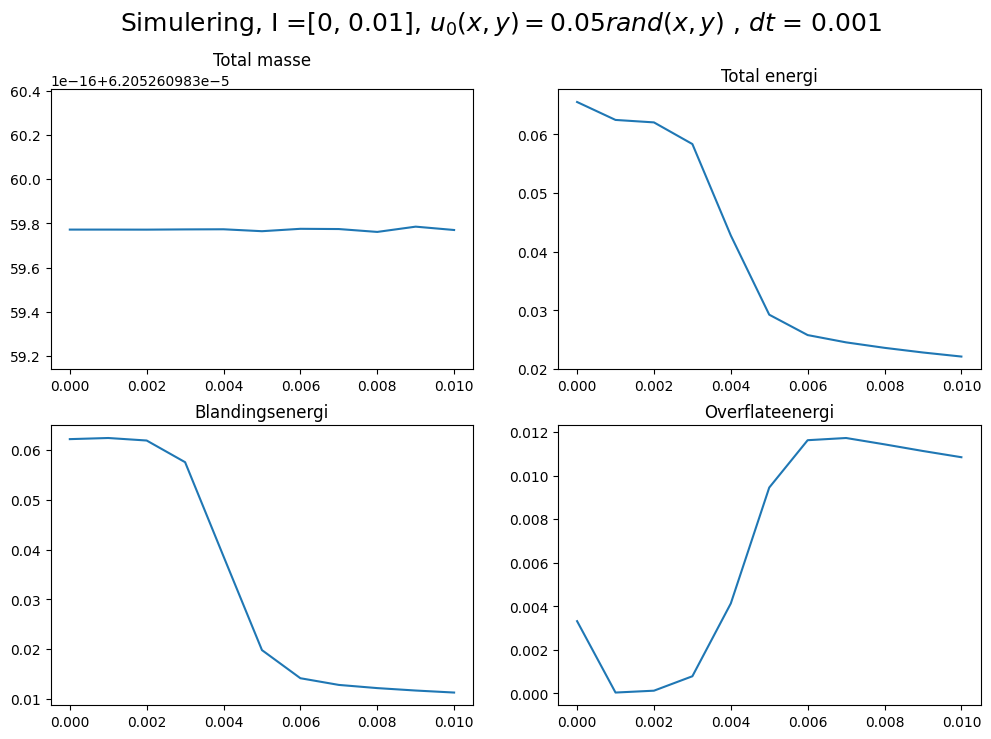

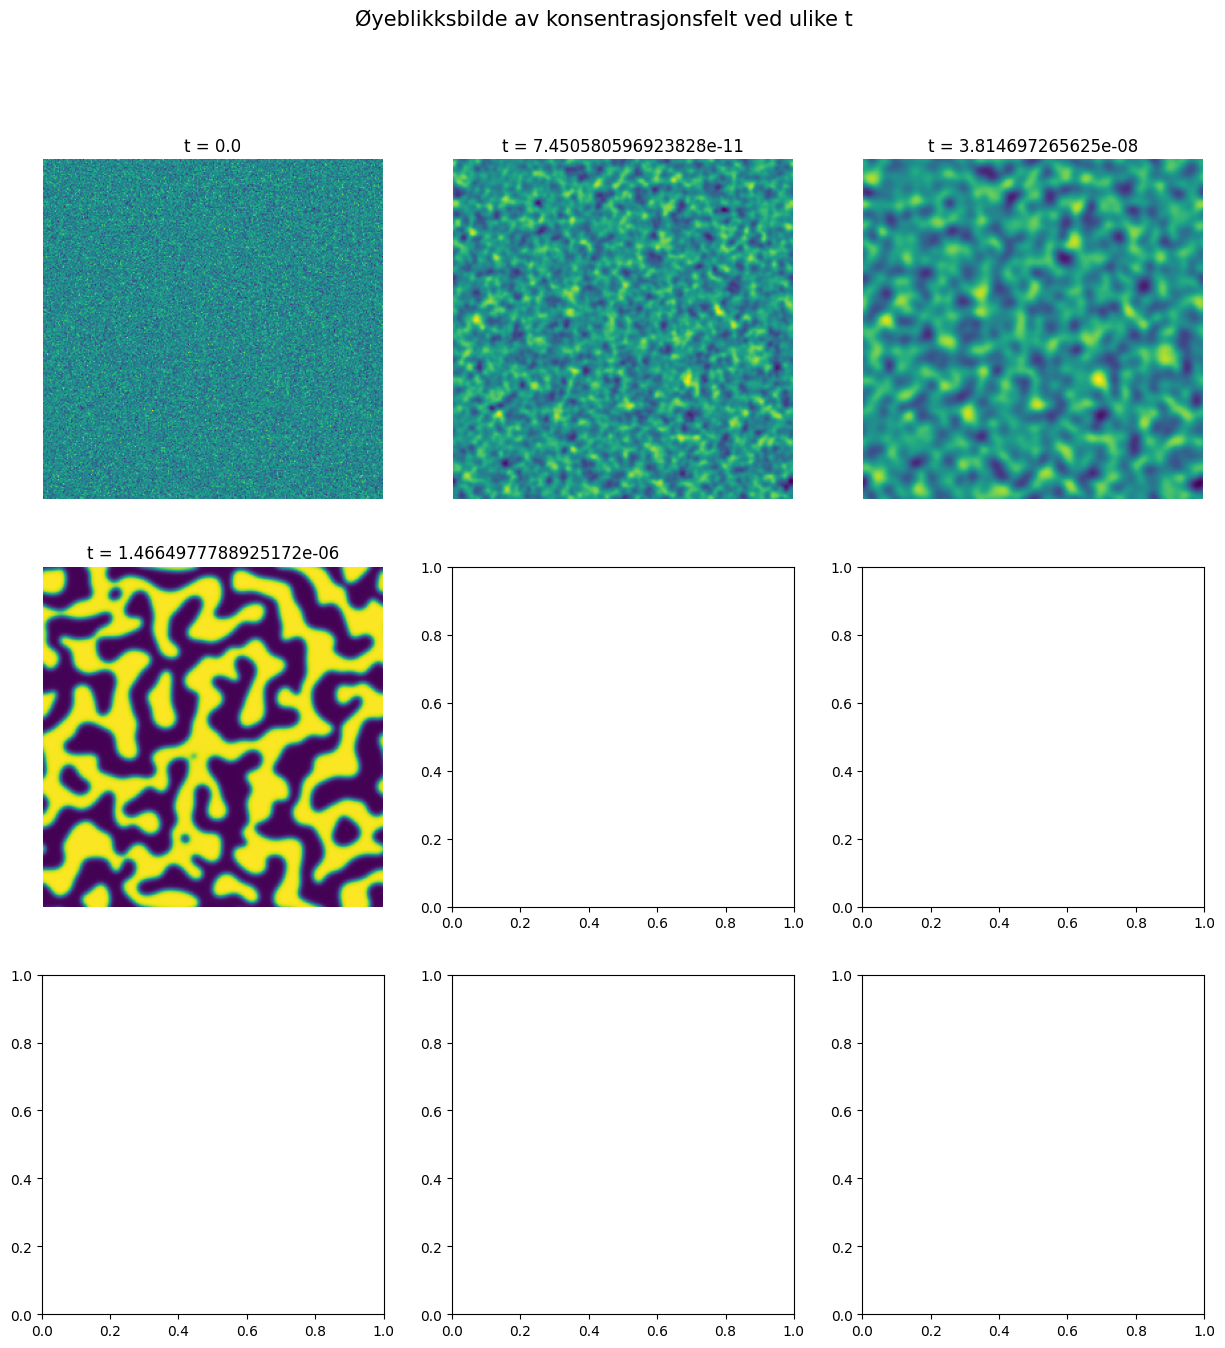

In [12]:
T = intervals[1]
U0 = U0s[0]
dt = dts[0]
solver = IMEX_solver(kappa = kappa, X = X, Y = Y, U0 = U0, t0 = t0, T = T, Nt = T/dt, g = None, coeff=coeff, alpha=1.5)

total_mass_list = []
mixing_energy_list = []
interface_energy_list = []
times_list = []

snapshot_indices = 9
# for å få flere snapshots på starten
snapshot_times = np.linspace(0, 1, snapshot_indices)**snapshot_indices 
snapshot_times = t0 + (T - t0) * snapshot_times 
snapshot_Us = []

for U_hat, t in solver:
    U = ifft2(U_hat).real
    for snapshot_time in snapshot_times:
        if abs(t - snapshot_time) < dt / 2:
            snapshot_Us.append(U)
            break
    times_list.append(t)
    total_mass_list.append(total_mass(U))
    mixing_energy_list.append(mixing_energy(U))
    interface_energy_list.append(interface_energy(kappa, U, Nx, Ny, Lx, Ly))

times_list = np.array(times_list)
total_mass_list = np.array(total_mass_list)
mixing_energy_list = np.array(mixing_energy_list)
interface_energy_list = np.array(interface_energy_list)
total_energy_list = mixing_energy_list + interface_energy_list

# Plotter total masse, blandingsenergi, overflateenergi og total energi
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
if np.array_equal(U0, U0s[0]):
    fig.suptitle(f'Simulering, I =[{t0}, {T}], $u_0(x, y) = 0.05 rand(x, y)$ , $dt$ = {dt}', fontsize=18)
else:
    fig.suptitle(f'Simulering, I =[{t0}, {T}], $u_0(x, y) = -0.45 + 0.05 rand(x, y)$ , $dt$ = {dt}', fontsize=18)

axs[0][0].plot(times_list, total_mass_list)
axs[0][0].set_title('Total masse')
axs[1][0].plot(times_list, mixing_energy_list)
axs[1][0].set_title('Blandingsenergi')
axs[1][1].plot(times_list, interface_energy_list)
axs[1][1].set_title('Overflateenergi')
axs[0][1].plot(times_list, total_energy_list)
axs[0][1].set_title('Total energi')

# plt.show()
# Plotter øyeblikksbilde av konsentrasjonsfelt u ved ulike tidssteg
cols = 3  # Number of columns for subplots
rows = (snapshot_indices + cols - 1) // cols  # Calculate rows needed
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
# axs = axs.flatten()
im = None
fig.suptitle('Øyeblikksbilde av konsentrasjonsfelt ved ulike t', fontsize=15)

for col in range(cols):
    for row in range(rows):
        i = rows * col + row
        if i < snapshot_indices:
            im = axs[col, row].imshow(snapshot_Us[i], cmap='viridis', origin='lower')
            axs[col, row].set_title(f't = {snapshot_times[i]}')
            axs[col, row].axis('off')

plt.tight_layout()
plt.show()

# # Create a figure and axis for the animation
# fig, ax = plt.subplots(figsize=(8, 6))
# im = ax.imshow(snapshot_Us[0], cmap='viridis', origin='lower')
# ax.set_title(f't = {snapshot_times[0]:.3f}')
# ax.axis('off')

# # Update function for the animation
# def update(frame):
#     im.set_array(snapshot_Us[frame])  # Update the data in the plot
#     ax.set_title(f't = {snapshot_times[frame]:.3f}')  # Update the title with the current time
#     return [im]

# # Create the animation
# ani = FuncAnimation(fig, update, frames=len(snapshot_Us), interval=200, blit=True)

# # Show the animation
# plt.show()